In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

Netflix Exploratory Data Analysis

In [78]:
data = pd.read_csv('netflix_titles.csv')
data.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [11]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [12]:
data.tail(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [13]:
data.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [14]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [15]:
data.columns
data.shape

(8807, 12)

In [16]:
data['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [17]:
movies= data[data['type'] == 'Movie'].copy()
movies['duration'].head(10)

0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
13     91 min
16     67 min
18     94 min
22    161 min
23     61 min
Name: duration, dtype: object

In [70]:
movies['duration_min']= (movies['duration'].str.extract(r'(\d+)').astype('Int64'))


C:\Users\utkar\AppData\Local\Temp\ipykernel_11828\3822537940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_min']= (movies['duration'].str.extract(r'(\d+)').astype('Int64'))


In [22]:
movies['duration_min'].max()
movies['duration_min'].min()
movies['duration_min'].describe()

count       6128.0
mean     99.577187
std      28.290593
min            3.0
25%           87.0
50%           98.0
75%          114.0
max          312.0
Name: duration_min, dtype: Float64

In [23]:
movies['duration'].isna().sum()

np.int64(3)

In [24]:
tv_shows=data[data['type']== 'TV Show'].copy()
tv_shows['duration'].head(10)

1     2 Seasons
2      1 Season
3      1 Season
4     2 Seasons
5      1 Season
8     9 Seasons
10     1 Season
11     1 Season
14     1 Season
15    4 Seasons
Name: duration, dtype: object

In [25]:
tv_shows['season']= (tv_shows['duration'].str.extract(r'(\d+)').astype('Int64'))

In [26]:
tv_shows['season'].max()
tv_shows['season'].min()
tv_shows['season'].describe()

count      2676.0
mean     1.764948
std      1.582752
min           1.0
25%           1.0
50%           1.0
75%           2.0
max          17.0
Name: season, dtype: Float64

In [27]:
tv_shows['duration'].isna().sum()

np.int64(0)

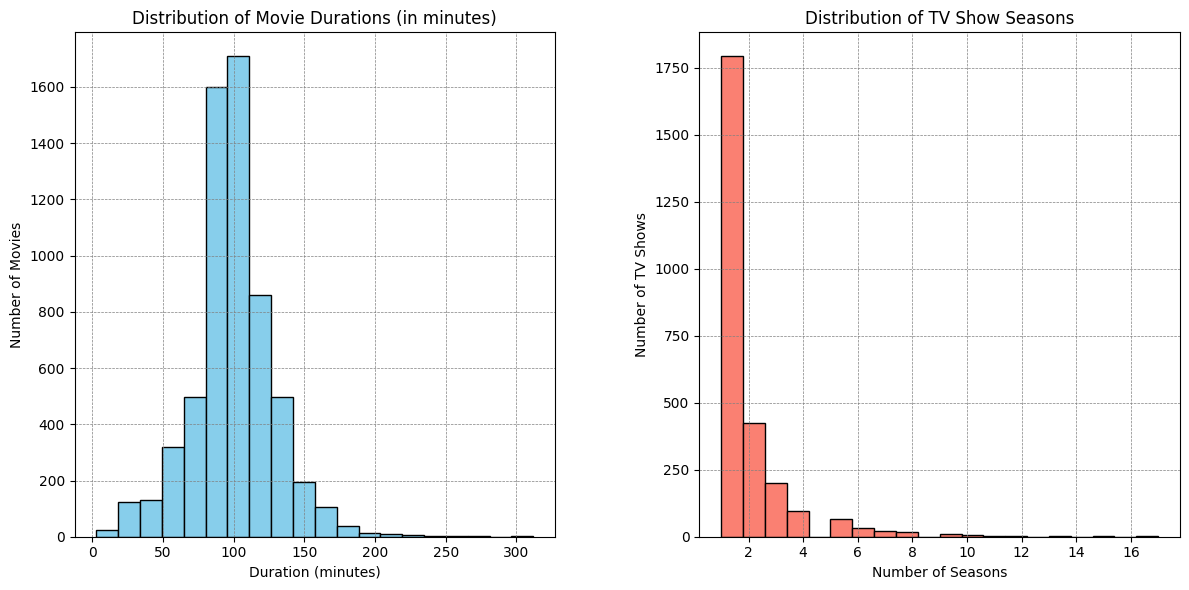

In [28]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].hist(movies['duration_min'], bins=20, color='skyblue', edgecolor='black')
ax[0].set_title('Distribution of Movie Durations (in minutes)')
ax[0].set_xlabel('Duration (minutes)')
ax[0].set_ylabel('Number of Movies')
ax[0].grid(color='gray', linestyle='--', linewidth=0.5)

ax[1].hist(tv_shows['season'], bins=20, color='salmon', edgecolor='black')
ax[1].set_title('Distribution of TV Show Seasons')
ax[1].set_xlabel('Number of Seasons')
ax[1].set_ylabel('Number of TV Shows')
ax[1].grid(color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)

In [29]:
data['country'].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [30]:
data['country'].head(10)

0                                        United States
1                                         South Africa
2                                                  NaN
3                                                  NaN
4                                                India
5                                                  NaN
6                                                  NaN
7    United States, Ghana, Burkina Faso, United Kin...
8                                       United Kingdom
9                                        United States
Name: country, dtype: object

In [31]:
top_countries= (data['country'].dropna().str.split(',').explode())

In [32]:
top_countries.value_counts().head(10)

country
United States     3211
India             1008
United Kingdom     628
 United States     479
Canada             271
Japan              259
France             212
South Korea        211
 France            181
Spain              181
Name: count, dtype: int64

(np.float64(-1.0999992320735141),
 np.float64(1.0999833081342627),
 np.float64(-1.0999783777228356),
 np.float64(1.099998927696565))

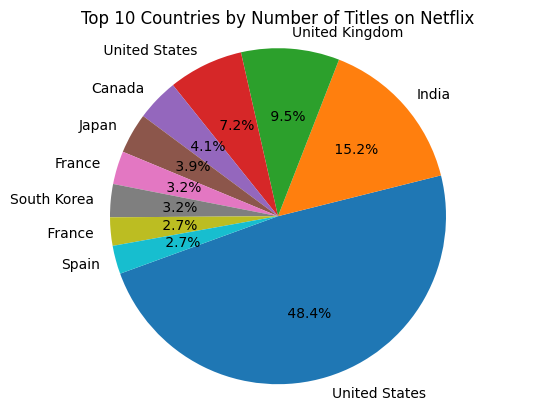

In [33]:
figsize=(12,8)
plt.pie(top_countries.value_counts().head(10), labels=top_countries.value_counts().head(10).index, autopct='% 1.1f%%', startangle=200)
plt.title('Top 10 Countries by Number of Titles on Netflix')
plt.axis('equal')

In [34]:
data['date_added'].head(10)

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: object

In [35]:
data['date_added']= pd.to_datetime(data['date_added'], errors='coerce')
data['date_added'].isna().sum()

np.int64(98)

In [36]:
data['year_added']= data['date_added'].dt.year
data[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [37]:
yearly_count= data['year_added'].value_counts().sort_index()
yearly_count

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

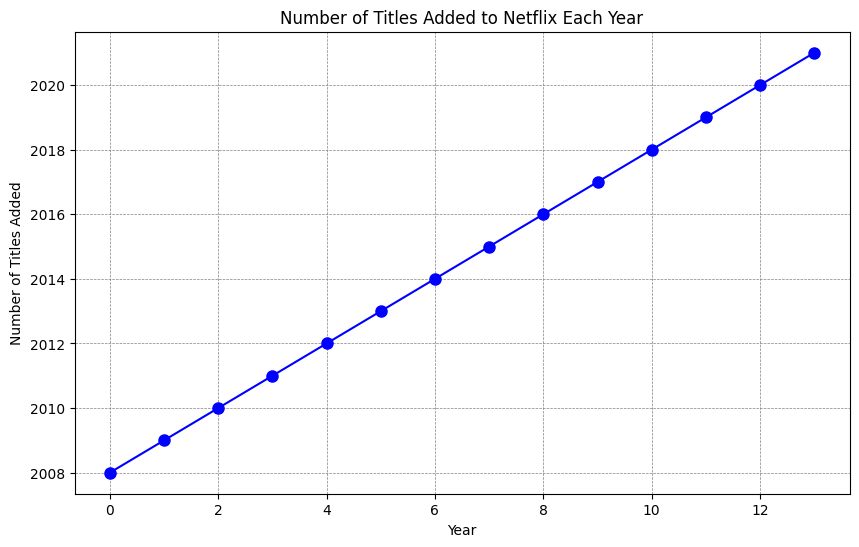

In [38]:
plt.figure(figsize=(10,6))
plt.plot(yearly_count.index, color='blue', marker='o', markersize=8)
plt.title('Number of Titles Added to Netflix Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(color='gray', linestyle='--', linewidth=0.5)

In [53]:
movies = data[data['type'] == 'Movie']
movies[['year_added']].head()
tv_shows= data[data['type']== 'TV Show']
tv_shows[['year_added']].head()

,year_added
1,2021.0
2,2021.0
3,2021.0
4,2021.0
5,2021.0


In [54]:
type(yearly_count)

pandas.core.series.Series

In [ ]:
movies[['type', 'year_added']].head()
movies[['type', 'year_added']].isna().sum()

,type,year_added
0,Movie,2021.0
6,Movie,2021.0
7,Movie,2021.0
9,Movie,2021.0
12,Movie,2021.0


In [41]:
movies.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'duration_min'],
      dtype='object')

In [51]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0


In [52]:
movies_peryear = movies['year_added'].value_counts().sort_index()

In [55]:
tv_shows.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0


In [ ]:
tv_shows_peryear = tv_shows['year_added'].value_counts().sort_index()

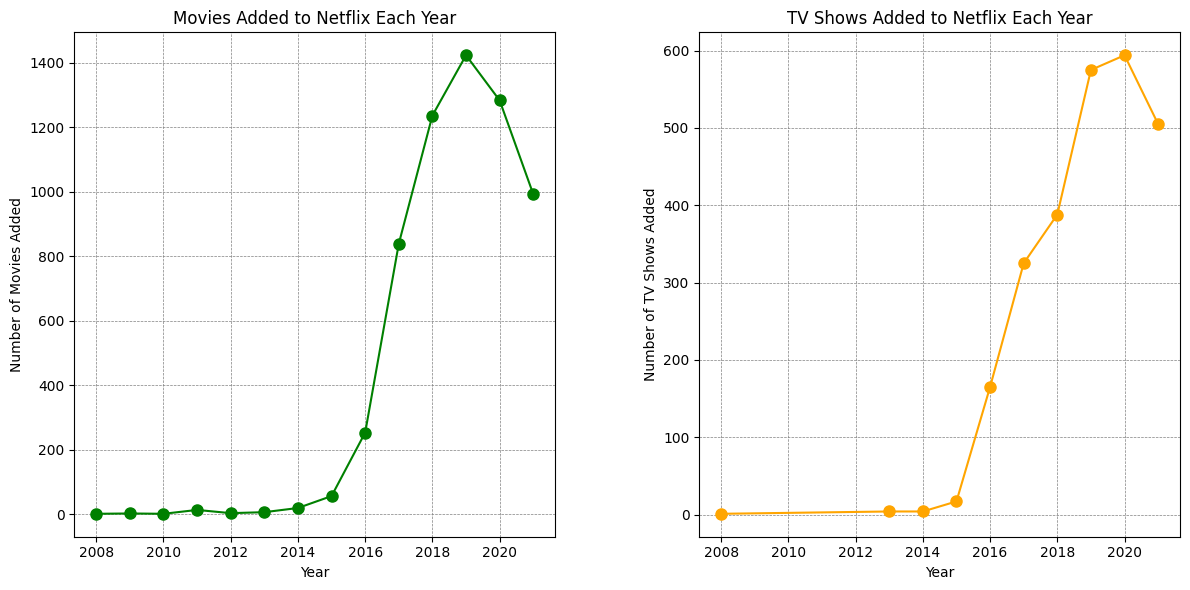

In [58]:
tv_shows_peryear = tv_shows['year_added'].value_counts().sort_index()

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].plot(movies_peryear.index, movies_peryear.values, color='green', marker='o', markersize=8)
ax[0].set_title('Movies Added to Netflix Each Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies Added')
ax[0].grid(color='gray', linestyle='--', linewidth=0.5)


ax[1].plot(tv_shows_peryear.index, tv_shows_peryear.values, color='orange', marker='o', markersize=8)
ax[1].set_title('TV Shows Added to Netflix Each Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows Added')
ax[1].grid(color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)

In [64]:
movies[['type', 'year_added']].head()


,type,year_added
0,Movie,2021.0
6,Movie,2021.0
7,Movie,2021.0
9,Movie,2021.0
12,Movie,2021.0


In [ ]:
avg_duration_per_year = (movies.groupby('year_added')['duration_min'].mean().sort_index())
avg_duration_per_year


year_added
2008.0          81.0
2009.0          66.5
2010.0          84.0
2011.0     93.461538
2012.0          62.0
2013.0          83.5
2014.0          77.0
2015.0     83.571429
2016.0     83.613546
2017.0     95.680191
2018.0    101.739693
2019.0     99.923455
2020.0     101.58567
2021.0    102.839879
Name: duration_min, dtype: Float64

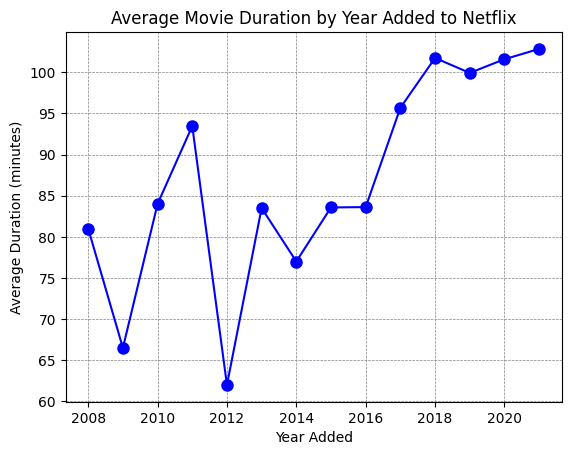

In [72]:
plt.figsize=(10,6)
plt.plot(avg_duration_per_year.index, avg_duration_per_year.values, color='blue', linestyle='-', marker='o', markersize=8)
plt.title('Average Movie Duration by Year Added to Netflix')
plt.xlabel('Year Added')
plt.ylabel('Average Duration (minutes)')
plt.grid(color='gray', linestyle='--', linewidth=0.5)

In [73]:
movies[['duration_min', 'year_added']].isna().sum()

duration_min    3
year_added      0
dtype: int64